<a href="https://colab.research.google.com/github/SujalGodse/Advance-Analytics-using-Statistics/blob/main/Advance_Analytics_using_Statistics_Day18.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **AUC and ROC Curve**

In [ ]:
from sklearn.metrics import roc_auc_score

In [ ]:
y_true = [1,0,0,1,1,0]
y_pred = [0.93,0.83,0.31,0.73,0.25,0.37]

In [ ]:
roc_auc_score(y_true,y_pred)

np.float64(0.5555555555555556)

In [ ]:
5/9

0.5555555555555556

In [ ]:
import statsmodels.api as sm
from statsmodels.formula.api import ols
import statsmodels.stats.multicomp
import sklearn
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression


import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)
from numpy import random
from collections import Counter
from numpy.linalg import inv
from numpy.linalg import eig
import matplotlib
from matplotlib import pyplot as plt
import seaborn as sns
import pylab
from pylab import legend
from pylab import plot, show, title, xlabel, ylabel
import scipy
from scipy import stats
from scipy.stats import binom,poisson,norm,t,expon,f
from sklearn.model_selection import train_test_split

import statsmodels
from statsmodels import stats
from statsmodels.stats import weightstats as ssw

import statsmodels.api as sm
from statsmodels.formula.api import ols
import statsmodels.stats.multicomp

from statsmodels.discrete.discrete_model import MNLogit

import statsmodels.stats
from statsmodels.stats.proportion import proportions_ztest

from scipy.stats import chisquare

from scipy.stats import chi2_contingency

from statsmodels.stats import rates
from statsmodels.stats.rates import test_poisson

from statsmodels.stats.rates import test_poisson_2indep

from scipy.stats import chi2

# **Nominal Logistic Regression**
It is used when your response is multi-categorical

In [ ]:
from statsmodels.discrete.discrete_model import MNLogit

In [ ]:
df = pd.read_excel('/content/drive/MyDrive/CDAC/CDAC_DataBook.xlsx', sheet_name='nominal')
df = df.drop('write', axis=1)

x = df.drop('prog', axis=1)
y = df.prog

ses_dummy = pd.get_dummies(x.ses, drop_first=True, prefix='SES').astype(int)
x.drop('ses', axis=1, inplace=True)
x = pd.concat([x,ses_dummy], axis=1)

x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2, random_state=20)

x_train = sm.add_constant(x_train, prepend=False)
mod1 = sm.MNLogit(y_train, x_train).fit()
print(mod1.summary())

Optimization terminated successfully.
         Current function value: 0.653667
         Iterations 8
                          MNLogit Regression Results                          
Dep. Variable:                   prog   No. Observations:                  160
Model:                        MNLogit   Df Residuals:                      152
Method:                           MLE   Df Model:                            6
Date:                Tue, 09 Jun 2026   Pseudo R-squ.:                  0.3687
Time:                        06:35:49   Log-Likelihood:                -104.59
converged:                       True   LL-Null:                       -165.68
Covariance Type:            nonrobust   LLR p-value:                 5.678e-24
    prog=2       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
math           0.0112      0.036      0.312      0.755      -0.059       0.082
SES_2          3.2174      0.

From above summary we can say ses has to be taken with respect to ses1 and prog with respect to prog1

math(continuous)  H0 ->  Maths score does not influence the choice between program 1 and program 2

SES_2(categorical) H0 -> whether we belong to ses 1 or ses 2, it does not influence the choice between prog1 and prog2

for continuous - as maths score increases then the probability of choosing prog2 over prog1 increases.

for categorical ses2 +ve - as we are move from ses1 to ses2 , so prob of taking prog2 increases and prog1 decreases.

for categorical ses3 if it is -ve - as we are moving from ses1 to ses3 , so prob of taking porg2 is going down and prob of taking prog1 is going up.

# **Ordinal Logistic Regression**

In [ ]:
from statsmodels.miscmodels.ordinal_model import OrderedModel

df = pd.read_excel('/content/drive/MyDrive/CDAC/CDAC_DataBook.xlsx', sheet_name='ordinal')

reg_dummy = pd.get_dummies(df.Region, drop_first=True, prefix='Region').astype(int)
df.drop('Region', axis=1, inplace=True)
df = pd.concat([df,reg_dummy], axis=1)
df.Survival = pd.Categorical(df.Survival, categories=[1,2,3],ordered=True)

x_train, x_test, y_train, y_test = train_test_split(df.drop('Survival',axis=1),df.Survival,test_size=0.2, random_state=20)

mod1=OrderedModel(y_train,x_train,distr='logit').fit(method='bfgs')
print(mod1.summary())

Optimization terminated successfully.
         Current function value: 0.847944
         Iterations: 19
         Function evaluations: 22
         Gradient evaluations: 22
                             OrderedModel Results                             
Dep. Variable:               Survival   Log-Likelihood:                -49.181
Model:                   OrderedModel   AIC:                             106.4
Method:            Maximum Likelihood   BIC:                             114.6
Date:                Tue, 09 Jun 2026                                         
Time:                        11:21:12                                         
No. Observations:                  58                                         
Df Residuals:                      54                                         
Df Model:                           2                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------

# **Counts Model**

## **Poisson**

Optimization terminated successfully.
         Current function value: 0.871654
         Iterations 6
                          Poisson Regression Results                          
Dep. Variable:             num_awards   No. Observations:                  160
Model:                        Poisson   Df Residuals:                      156
Method:                           MLE   Df Model:                            3
Date:                Tue, 09 Jun 2026   Pseudo R-squ.:                  0.1865
Time:                        11:53:40   Log-Likelihood:                -139.46
converged:                       True   LL-Null:                       -171.44
Covariance Type:            nonrobust   LLR p-value:                 8.447e-14
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -5.0741      0.780     -6.503      0.000      -6.603      -3.545
math           0.0661      0.

(array([124.,  49.,   0.,  13.,   0.,   9.,   2.,   0.,   2.,   1.]),
 array([0. , 0.6, 1.2, 1.8, 2.4, 3. , 3.6, 4.2, 4.8, 5.4, 6. ]),
 <BarContainer object of 10 artists>)

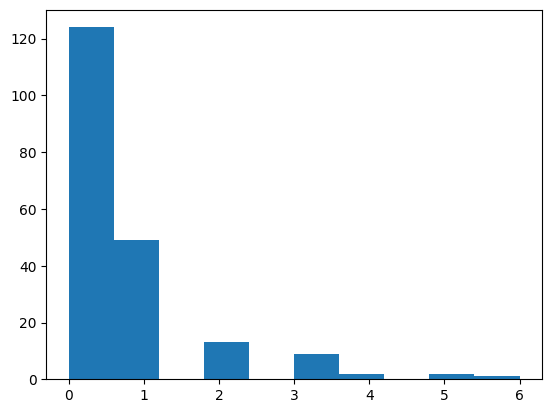

In [ ]:
import statsmodels.formula.api as smf
from statsmodels.discrete.discrete_model import Poisson as psn
df = pd.read_excel('/content/drive/MyDrive/CDAC/CDAC_DataBook.xlsx', sheet_name='poisson')
prog_dummy = pd.get_dummies(df.prog, drop_first=True,prefix='prog').astype(int)
df = df.drop('prog', axis=1)
df = pd.concat([df,prog_dummy], axis=1)
x_train, x_test, y_train, y_test = train_test_split(df.drop('num_awards', axis=1), df['num_awards'], test_size=0.2,random_state=20)
x_train1 = sm.add_constant(x_train, prepend=False)

df_train = pd.concat([x_train1,y_train], axis=1)

mod2 = psn.from_formula("num_awards ~ math+prog_2+prog_3", data=df_train).fit()
print(mod2.summary())

plt.hist(df.num_awards)

In [ ]:
mydata = pd.DataFrame([[50,1,0],[60,1,0],[70,1,0]],columns=x_train.columns)
print(mydata)
mod2.predict(mydata)

   math  prog_2  prog_3
0    50       1       0
1    60       1       0
2    70       1       0


,0
0,0.513868
1,0.994929
2,1.926336


In [ ]:
mydata = pd.DataFrame([[70,0,0],[70,1,0],[70,0,1]],columns=x_train.columns)
print(mydata)
mod2.predict(mydata)

   math  prog_2  prog_3
0    70       0       0
1    70       1       0
2    70       0       1


,0
0,0.638170
1,1.926336
2,0.920868


# **Negative Binomial**

In [ ]:
from statsmodels.discrete.discrete_model import NegativeBinomial as ngb
df = pd.read_excel('/content/drive/MyDrive/CDAC/CDAC_DataBook.xlsx', sheet_name='neg_bin')
prog_dummy = pd.get_dummies(df['prog'], drop_first=True,prefix='prog').astype(int)
df = df.drop('prog', axis=1)
df = pd.concat([df,prog_dummy], axis=1)
x_train, x_test, y_train, y_test = train_test_split(df.drop('daysabs',axis=1), df['daysabs'], test_size=0.2,random_state=20)
x_train1 = sm.add_constant(x_train)
df_train = pd.concat([x_train1,y_train], axis=1)
model3 = ngb.from_formula("daysabs ~ math+prog_General+prog_Vocational", data=df_train).fit()
print(model3.summary())

Optimization terminated successfully.
         Current function value: 2.819371
         Iterations: 19
         Function evaluations: 26
         Gradient evaluations: 26
                     NegativeBinomial Regression Results                      
Dep. Variable:                daysabs   No. Observations:                  251
Model:               NegativeBinomial   Df Residuals:                      247
Method:                           MLE   Df Model:                            3
Date:                Tue, 09 Jun 2026   Pseudo R-squ.:                 0.03229
Time:                        11:56:11   Log-Likelihood:                -707.66
converged:                       True   LL-Null:                       -731.28
Covariance Type:            nonrobust   LLR p-value:                 3.104e-10
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           2.2587  

In [ ]:
mydata = pd.DataFrame([[60,0,0],[60,1,0],[60,0,1]],columns=x_train.columns)
print(mydata)
model3.predict(mydata)

   math  prog_General  prog_Vocational
0    60             0                0
1    60             1                0
2    60             0                1


,0
0,6.285376
1,9.322562
2,3.002024
